# Chili Price Forecasting

Notebook ini bertujuan untuk membangun model prediksi harga cabai rawit berdasarkan data historis harian. Target prediksi yang digunakan adalah harga cabai rawit 3 hari ke depan.

Tahapan analisis:
1. Memuat dan membersihkan data harga cabai rawit harian.
2. Melakukan exploratory data analysis untuk memahami tren, distribusi, volatilitas, dan pola musiman harga.
3. Membuat fitur time series seperti lag, rolling statistics, dan fitur kalender.
4. Melatih dan membandingkan beberapa model machine learning.
5. Mengevaluasi performa model terhadap baseline sederhana.

Output utama notebook:
- Insight tren harga cabai rawit.
- Perbandingan performa model prediksi.
- Model terbaik untuk prediksi harga cabai rawit 3 hari ke depan.

## Package Import

In [335]:
# Basic libraries
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy.stats import skew, kurtosis

# Machine learning models
from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# Model evaluation and validation
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

# Global settings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

## Data Collection

In [336]:
# Define data path
DATA_PATH = Path("dataset/cabai_rawit_combined.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset tidak ditemukan pada path: {DATA_PATH}")

# Load dataset
raw_df = pd.read_csv(DATA_PATH)

# Preview data
print("Dataset shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.info())

Dataset shape: (1604, 2)


,Date,Price
0,01/01/2022,"76,357.00"
1,02/01/2022,"72,846.00"
2,03/01/2022,"68,357.00"
3,04/01/2022,"53,462.00"
4,05/01/2022,"52,692.00"


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1604 entries, 0 to 1603
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1604 non-null   object 
 1   Price   1542 non-null   float64
dtypes: float64(1), object(1)
memory usage: 25.2+ KB


None

In [337]:
required_columns = ["Date", "Price"]

missing_columns = [col for col in required_columns if col not in raw_df.columns]

if missing_columns:
    raise ValueError(f"Kolom berikut tidak ditemukan dalam dataset: {missing_columns}")

In [338]:
chili_df = raw_df.copy()

### Data Cleaning

In [339]:
print("Jumlah baris awal:", len(chili_df))
print("Jumlah missing Date:", chili_df["Date"].isna().sum())
print("Jumlah missing Price:", chili_df["Price"].isna().sum())

print("\nContoh data awal:")
display(chili_df.head())

print("\nStatistik awal Price:")
display(chili_df["Price"].describe())

Jumlah baris awal: 1604
Jumlah missing Date: 0
Jumlah missing Price: 62

Contoh data awal:


,Date,Price
0,01/01/2022,"76,357.00"
1,02/01/2022,"72,846.00"
2,03/01/2022,"68,357.00"
3,04/01/2022,"53,462.00"
4,05/01/2022,"52,692.00"



Statistik awal Price:


count     1,542.00
mean     50,881.96
std      20,397.56
min      24,077.00
25%      34,103.75
50%      43,879.50
75%      65,787.25
max     114,246.00
Name: Price, dtype: float64

In [340]:
chili_df['Date'] = pd.to_datetime(
    chili_df['Date'],
    format='%d/%m/%Y',
    errors='coerce'
)

# Create complete daily date range
full_dates = pd.date_range(
    start=chili_df["Date"].min(),
    end=chili_df["Date"].max(),
    freq="D"
)

# Reindex to daily frequency
chili_df = (
    chili_df
    .set_index("Date")
    .reindex(full_dates)
    .rename_axis("Date")
    .reset_index()
)

# Mark missing price before imputation
chili_df["is_price_imputed"] = chili_df["Price"].isna().astype(int)

missing_after_reindex = chili_df["Price"].isna().sum()
print("Jumlah tanggal tanpa data harga setelah reindex:", missing_after_reindex)

# Interpolate missing prices
chili_df["Price"] = chili_df["Price"].interpolate()

# Drop remaining missing values if the first date has no price
chili_df = chili_df.dropna(subset=["Price"]).reset_index(drop=True)

print("Jumlah data setelah cleaning:", len(chili_df))
print("Rentang tanggal:", chili_df["Date"].min(), "sampai", chili_df["Date"].max())

display(chili_df.head())

Jumlah tanggal tanpa data harga setelah reindex: 62
Jumlah data setelah cleaning: 1604
Rentang tanggal: 2022-01-01 00:00:00 sampai 2026-05-23 00:00:00


,Date,Price,is_price_imputed
0,2022-01-01,"76,357.00",0
1,2022-01-02,"72,846.00",0
2,2022-01-03,"68,357.00",0
3,2022-01-04,"53,462.00",0
4,2022-01-05,"52,692.00",0


In [341]:
invalid_price = chili_df[
    (chili_df["Price"].isna()) |
    (chili_df["Price"] <= 0)
]

print("Jumlah harga tidak valid:", len(invalid_price))

if len(invalid_price) > 0:
    display(invalid_price.head())

Jumlah harga tidak valid: 0


In [342]:
cleaning_summary = pd.DataFrame({
    "Metric": [
        "Start Date",
        "End Date",
        "Total Observations",
        "Missing Price After Cleaning",
        "Imputed Price Count",
        "Minimum Price",
        "Maximum Price",
        "Average Price"
    ],
    "Value": [
        chili_df["Date"].min(),
        chili_df["Date"].max(),
        len(chili_df),
        chili_df["Price"].isna().sum(),
        chili_df["is_price_imputed"].sum(),
        chili_df["Price"].min(),
        chili_df["Price"].max(),
        chili_df["Price"].mean()
    ]
})

display(cleaning_summary)

,Metric,Value
0,Start Date,2022-01-01 00:00:00
1,End Date,2026-05-23 00:00:00
2,Total Observations,1604
3,Missing Price After Cleaning,0
4,Imputed Price Count,62
5,Minimum Price,"24,077.00"
6,Maximum Price,"114,246.00"
7,Average Price,"50,756.26"


Setelah proses pembersihan data, dataset disusun dalam frekuensi harian dari tanggal awal hingga tanggal akhir pengamatan. Jika terdapat tanggal yang tidak memiliki data harga, nilai harga diisi menggunakan metode forward fill, yaitu menggunakan harga terakhir yang tersedia. Penanda `is_price_imputed` ditambahkan untuk menunjukkan apakah suatu observasi merupakan hasil imputasi atau bukan.

Penggunaan forward fill dipilih karena data harga harian umumnya memiliki keterkaitan kuat dengan harga pada hari sebelumnya. Namun, metode ini tetap memiliki keterbatasan karena dapat meratakan perubahan harga pada periode tanpa pencatatan.

## Exploratory Data Analysis

Pada bagian ini dilakukan eksplorasi data harga cabai rawit untuk memahami pola umum data sebelum masuk ke tahap pemodelan. Analisis mencakup statistik deskriptif, sebaran harga, outlier, pola tren harian, pola bulanan, pola tahunan, serta perbandingan harga antar tahun.

Tujuan utama EDA adalah memastikan bahwa data memiliki pola historis yang dapat digunakan untuk membangun model prediksi harga.

### Descriptive Analysis

In [343]:
price_summary = chili_df["Price"].describe().to_frame(name="Price")

additional_stats = pd.DataFrame({
    "Price": {
        "median": chili_df["Price"].median(),
        "variance": chili_df["Price"].var(),
        "std_dev": chili_df["Price"].std(),
        "skewness": chili_df["Price"].skew(),
        "kurtosis": chili_df["Price"].kurtosis(),
        "coefficient_of_variation": chili_df["Price"].std() / chili_df["Price"].mean()
    }
})

summary_stats = pd.concat([price_summary, additional_stats])
display(summary_stats)

,Price
count,"1,604.00"
mean,"50,756.26"
std,"20,009.04"
min,"24,077.00"
25%,"34,371.50"
50%,"45,220.00"
75%,"64,818.25"
max,"114,246.00"
median,"45,220.00"
variance,"400,361,603.56"


Statistik deskriptif menunjukkan rentang dan variasi harga cabai rawit selama periode pengamatan. Nilai standar deviasi dan coefficient of variation digunakan untuk melihat tingkat volatilitas harga. Jika coefficient of variation cukup tinggi, maka harga cabai rawit dapat dikatakan memiliki fluktuasi yang besar relatif terhadap rata-ratanya.

## Outliers Analysis

In [344]:
Q1 = chili_df["Price"].quantile(0.25)
Q2 = chili_df["Price"].quantile(0.50)
Q3 = chili_df["Price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = chili_df[
    (chili_df["Price"] < lower_bound) |
    (chili_df["Price"] > upper_bound)
].copy()

outlier_summary = pd.DataFrame({
    "Metric": [
        "Q1",
        "Median",
        "Q3",
        "IQR",
        "Lower Bound",
        "Upper Bound",
        "Total Outliers",
        "Outlier Percentage"
    ],
    "Value": [
        Q1,
        Q2,
        Q3,
        IQR,
        lower_bound,
        upper_bound,
        len(outliers),
        len(outliers) / len(chili_df) * 100
    ]
})

display(outlier_summary)
display(outliers[["Date", "Price"]].head(10))

,Metric,Value
0,Q1,"34,371.50"
1,Median,"45,220.00"
2,Q3,"64,818.25"
3,IQR,"30,446.75"
4,Lower Bound,"-11,298.62"
5,Upper Bound,"110,488.38"
6,Total Outliers,1.00
7,Outlier Percentage,0.06


,Date,Price
1157,2025-03-03,"114,246.00"


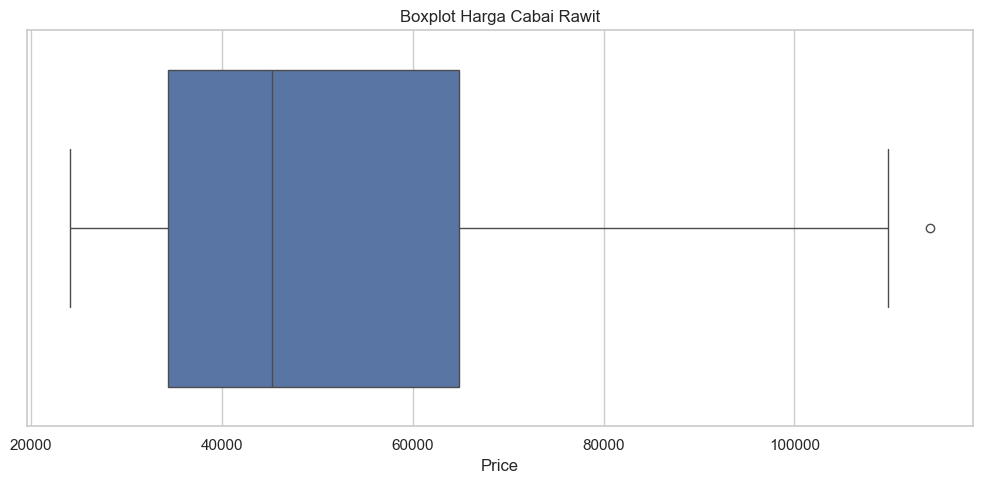

In [345]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=chili_df["Price"])

plt.title("Boxplot Harga Cabai Rawit")
plt.xlabel("Price")
plt.tight_layout()
plt.show()

In [346]:
outliers = chili_df[
    (chili_df['Price'] < lower_bound) |
    (chili_df['Price'] > upper_bound)
]

print("Total Outliers:", len(outliers))

outlier_percentage = (
    len(outliers) / len(chili_df)
) * 100

print(f"Outlier Percentage: {outlier_percentage:.2f}%")

print("\nSample Outliers:")
print(outliers.head())

Total Outliers: 1
Outlier Percentage: 0.06%

Sample Outliers:
           Date      Price  is_price_imputed
1157 2025-03-03 114,246.00                 0


In [347]:
outliers[['Date', 'Price']]

,Date,Price
1157,2025-03-03,"114,246.00"


Terdapat satu outlier yang terlihat pada boxplot tersebut. Outlier tersebut tidak langsung dihapus karena lonjakan harga dapat merepresentasikan kondisi pasar yang penting, seperti gangguan pasokan, peningkatan permintaan, atau faktor musiman. Oleh karena itu, outlier diperlakukan sebagai bagian dari dinamika harga, bukan sebagai data error, kecuali terdapat bukti bahwa nilai tersebut berasal dari kesalahan pencatatan.

## Distribution Analysis

Skewness : 0.8074
Kurtosis : -0.2390
Mean     : 50756.26
Median   : 45220.00


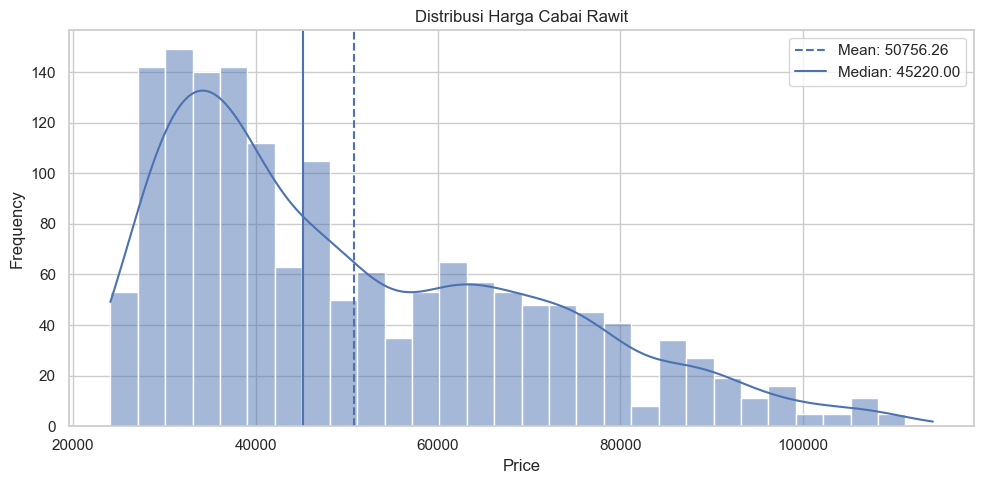

In [348]:
price_clean = chili_df["Price"].dropna()

skewness = price_clean.skew()
kurt = price_clean.kurtosis()
mean_price = price_clean.mean()
median_price = price_clean.median()

print(f"Skewness : {skewness:.4f}")
print(f"Kurtosis : {kurt:.4f}")
print(f"Mean     : {mean_price:.2f}")
print(f"Median   : {median_price:.2f}")

plt.figure(figsize=(10, 5))

sns.histplot(price_clean, bins=30, kde=True)

plt.axvline(mean_price, linestyle="--", label=f"Mean: {mean_price:.2f}")
plt.axvline(median_price, linestyle="-", label=f"Median: {median_price:.2f}")

plt.title("Distribusi Harga Cabai Rawit")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

Distribusi harga digunakan untuk melihat apakah data cenderung simetris atau condong ke salah satu sisi. Nilai skewness menunjukkan arah kemencengan distribusi, sedangkan kurtosis menunjukkan ketebalan ekor distribusi. Pada data harga komoditas, distribusi yang tidak simetris cukup wajar karena harga dapat mengalami lonjakan pada periode tertentu.

### Tren Harga Cabai

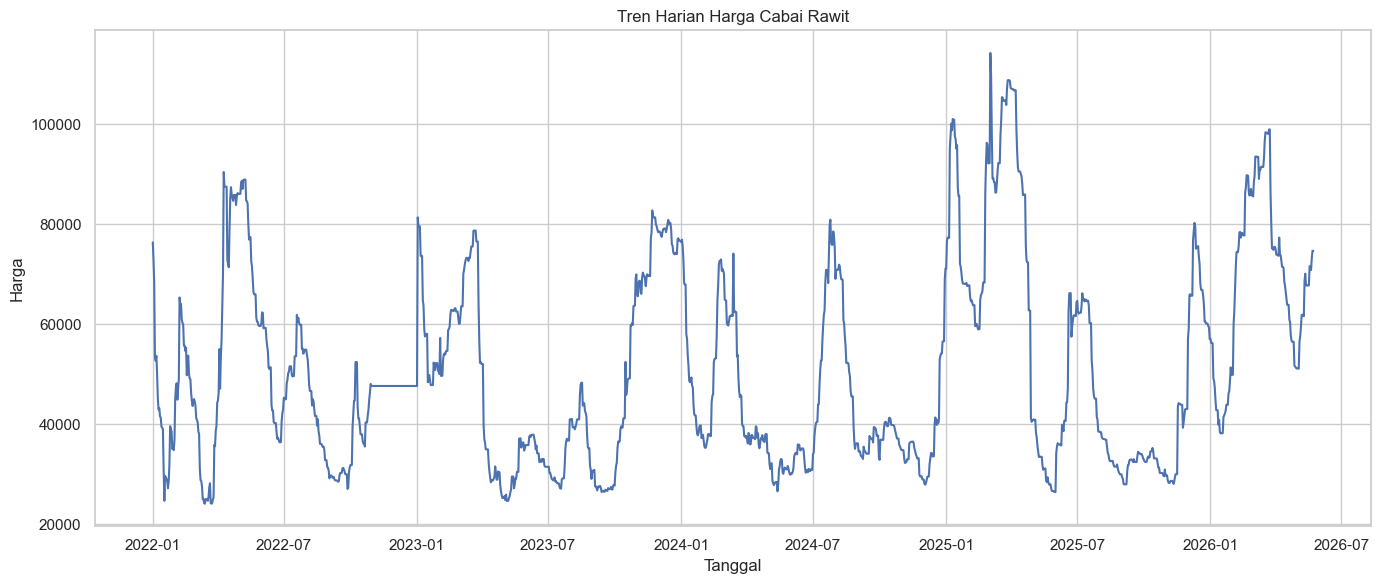

In [349]:
# Tren Harian
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=chili_df,
    x="Date",
    y="Price"
)

plt.title("Tren Harian Harga Cabai Rawit")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.tight_layout()
plt.show()

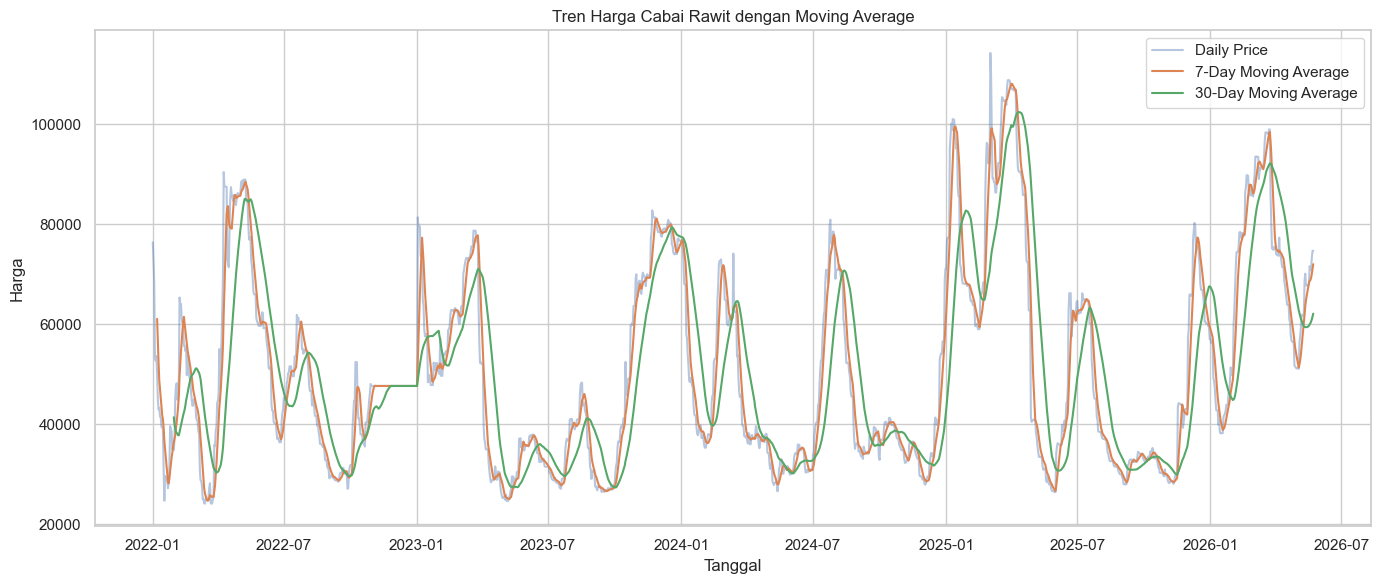

In [350]:
chili_df["Price_MA7"] = chili_df["Price"].rolling(window=7).mean()
chili_df["Price_MA30"] = chili_df["Price"].rolling(window=30).mean()

plt.figure(figsize=(14, 6))

plt.plot(chili_df["Date"], chili_df["Price"], label="Daily Price", alpha=0.4)
plt.plot(chili_df["Date"], chili_df["Price_MA7"], label="7-Day Moving Average")
plt.plot(chili_df["Date"], chili_df["Price_MA30"], label="30-Day Moving Average")

plt.title("Tren Harga Cabai Rawit dengan Moving Average")
plt.xlabel("Tanggal")
plt.ylabel("Harga")
plt.legend()
plt.tight_layout()
plt.show()

Moving average digunakan untuk memperhalus fluktuasi harian sehingga tren umum harga lebih mudah terlihat. Rata-rata bergerak 7 hari menunjukkan perubahan jangka pendek, sedangkan rata-rata bergerak 30 hari membantu melihat kecenderungan harga dalam periode yang lebih panjang.

,Date,average_price,min_price,max_price,std_price
0,2022-01-31,"41,226.97","24,667.00","76,357.00","13,004.26"
1,2022-02-28,"51,795.39","43,643.00","65,333.00","6,768.15"
2,2022-03-31,"30,781.55","24,077.00","44,286.00","7,090.61"
3,2022-04-30,"76,190.20","44,692.00","90,417.00","14,662.30"
4,2022-05-31,"74,699.94","59,639.00","88,904.00","11,499.10"


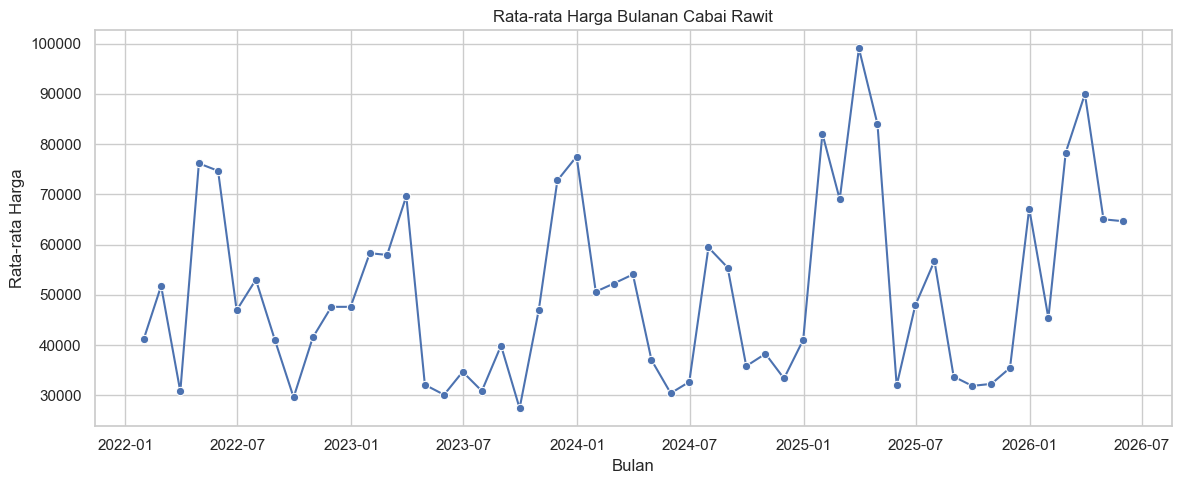

In [351]:
# Tren Bulanan
monthly = (
    chili_df
    .set_index("Date")
    .resample("ME")
    .agg(
        average_price=("Price", "mean"),
        min_price=("Price", "min"),
        max_price=("Price", "max"),
        std_price=("Price", "std")
    )
    .reset_index()
)

display(monthly.head())

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly,
    x="Date",
    y="average_price",
    marker="o"
)

plt.title("Rata-rata Harga Bulanan Cabai Rawit")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Harga")
plt.tight_layout()
plt.show()

,Date,average_price,min_price,max_price,std_price
0,2022-12-31,"48,456.18","24,077.00","90,417.00","16,095.70"
1,2023-12-31,"48,199.41","24,645.00","82,740.00","18,762.93"
2,2024-12-31,"43,428.55","26,560.00","80,899.00","13,690.58"
3,2025-12-31,"55,913.94","26,417.00","114,246.00","25,032.80"
4,2026-12-31,"68,743.50","38,160.00","98,940.00","17,376.65"


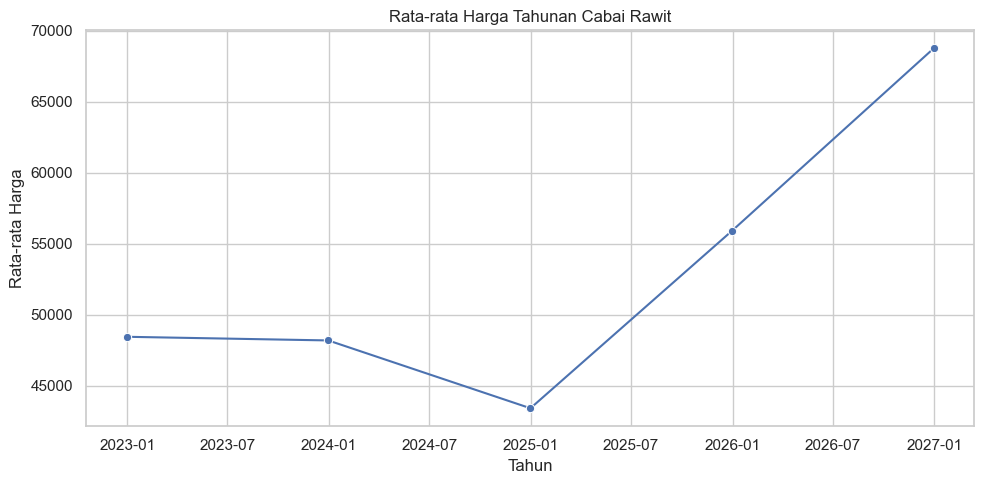

In [352]:
# Tren Tahunan
yearly = (
    chili_df
    .set_index("Date")
    .resample("YE")
    .agg(
        average_price=("Price", "mean"),
        min_price=("Price", "min"),
        max_price=("Price", "max"),
        std_price=("Price", "std")
    )
    .reset_index()
)

display(yearly)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=yearly,
    x="Date",
    y="average_price",
    marker="o"
)

plt.title("Rata-rata Harga Tahunan Cabai Rawit")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Harga")
plt.tight_layout()
plt.show()

Analisis bulanan dan tahunan digunakan untuk melihat perubahan harga dalam horizon waktu yang lebih panjang. Rata-rata bulanan membantu mengidentifikasi potensi pola musiman, sedangkan rata-rata tahunan memberi gambaran perubahan harga dari tahun ke tahun.

### Perbandingan Harga Antar Tahun

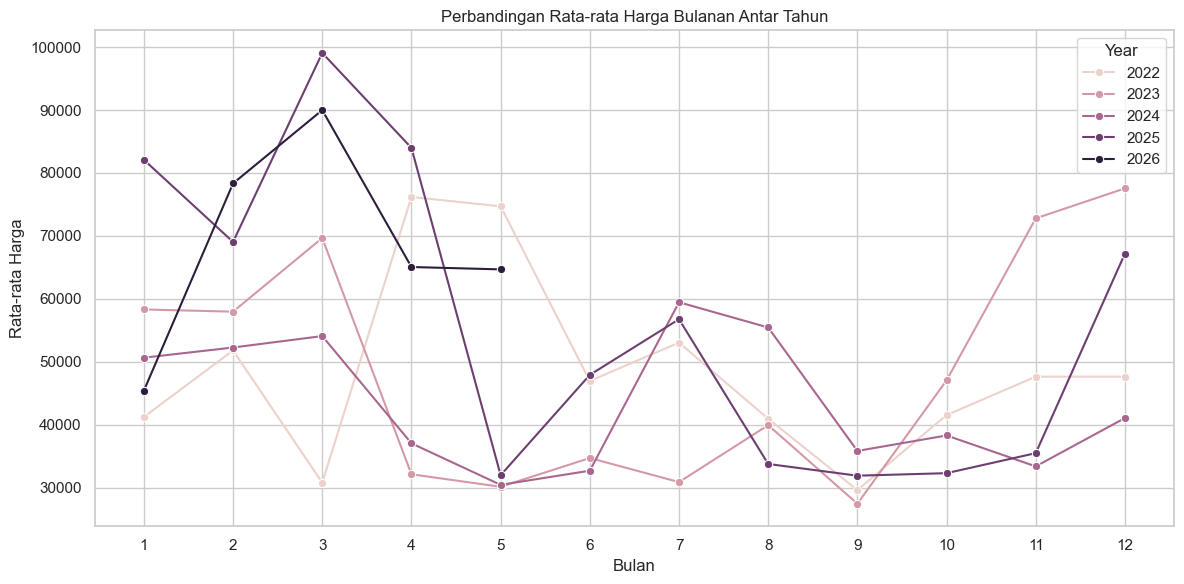

In [353]:
year_month_df = chili_df.copy()

year_month_df["Year"] = year_month_df["Date"].dt.year
year_month_df["Month"] = year_month_df["Date"].dt.month

monthly_by_year = (
    year_month_df
    .groupby(["Year", "Month"], as_index=False)
    .agg(average_price=("Price", "mean"))
)

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=monthly_by_year,
    x="Month",
    y="average_price",
    hue="Year",
    marker="o"
)

plt.title("Perbandingan Rata-rata Harga Bulanan Antar Tahun")
plt.xlabel("Bulan")
plt.ylabel("Rata-rata Harga")
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

Perbandingan rata-rata harga bulanan antar tahun digunakan untuk melihat apakah terdapat pola musiman yang berulang. Jika harga cenderung meningkat pada bulan-bulan tertentu secara konsisten, maka informasi tersebut dapat menjadi fitur penting untuk model prediksi.

## Data Preprocessing

### Feature Engineering

Pada tahap ini dilakukan pembuatan fitur untuk kebutuhan prediksi harga cabai rawit. Target yang digunakan adalah harga cabai rawit 3 hari ke depan. Oleh karena itu, setiap baris data merepresentasikan informasi historis yang tersedia pada hari tertentu untuk memprediksi harga pada 3 hari setelahnya.

In [354]:
df = chili_df.copy()

HORIZON = 3

df["target_date"] = df["Date"].shift(-HORIZON)
df["target_price"] = df["Price"].shift(-HORIZON)

print(f"Prediction horizon: {HORIZON} days ahead")
display(df[["Date", "Price", "target_date", "target_price"]].head(10))

df = df.dropna(subset=["target_date", "target_price"]).reset_index(drop=True)

df["target_year"] = df["target_date"].dt.year
df["target_month"] = df["target_date"].dt.month
df["target_day"] = df["target_date"].dt.day
df["target_dayofweek"] = df["target_date"].dt.dayofweek
df["target_weekofyear"] = df["target_date"].dt.isocalendar().week.astype(int)

df["target_month_sin"] = np.sin(2 * np.pi * df["target_month"] / 12)
df["target_month_cos"] = np.cos(2 * np.pi * df["target_month"] / 12)

df["target_dow_sin"] = np.sin(2 * np.pi * df["target_dayofweek"] / 7)
df["target_dow_cos"] = np.cos(2 * np.pi * df["target_dayofweek"] / 7)

Prediction horizon: 3 days ahead


,Date,Price,target_date,target_price
0,2022-01-01,"76,357.00",2022-01-04,"53,462.00"
1,2022-01-02,"72,846.00",2022-01-05,"52,692.00"
2,2022-01-03,"68,357.00",2022-01-06,"53,636.00"
3,2022-01-04,"53,462.00",2022-01-07,"50,000.00"
4,2022-01-05,"52,692.00",2022-01-08,"45,000.00"
5,2022-01-06,"53,636.00",2022-01-09,"42,923.00"
6,2022-01-07,"50,000.00",2022-01-10,"43,214.00"
7,2022-01-08,"45,000.00",2022-01-11,"41,538.00"
8,2022-01-09,"42,923.00",2022-01-12,"41,333.00"
9,2022-01-10,"43,214.00",2022-01-13,"39,500.00"


In [355]:
df["current_price"] = df["Price"]

lags = [1, 2, 3, 7, 14, 21, 30]

for lag in lags:
    df[f"lag_{lag}"] = df["Price"].shift(lag)

In [356]:
df["rolling_mean_3"] = df["Price"].rolling(3).mean()
df["rolling_mean_7"] = df["Price"].rolling(7).mean()
df["rolling_mean_14"] = df["Price"].rolling(14).mean()
df["rolling_mean_30"] = df["Price"].rolling(30).mean()

df["rolling_std_7"] = df["Price"].rolling(7).std()
df["rolling_std_14"] = df["Price"].rolling(14).std()

df["rolling_min_7"] = df["Price"].rolling(7).min()
df["rolling_max_7"] = df["Price"].rolling(7).max()

df["diff_1"] = df["Price"].diff(1)
df["diff_7"] = df["Price"].diff(7)
df["pct_change_1"] = df["Price"].pct_change(1)
df["pct_change_7"] = df["Price"].pct_change(7)

## Features Preparation

In [357]:
features = [
    "current_price",

    "lag_1",
    "lag_2",
    "lag_3",
    "lag_7",
    "lag_14",
    "lag_21",
    "lag_30",

    "rolling_mean_3",
    "rolling_mean_7",
    "rolling_mean_14",
    "rolling_mean_30",

    "rolling_std_7",
    "rolling_std_14",

    "rolling_min_7",
    "rolling_max_7",

    "diff_1",
    "diff_7",
    "pct_change_1",
    "pct_change_7",

    "target_month_sin",
    "target_month_cos",
    "target_dow_sin",
    "target_dow_cos",

    "target_dayofweek",
    "target_weekofyear"
]

target = "target_price"

df = df.dropna().reset_index(drop=True)

print("Final modeling dataset shape:", df.shape)
display(df[["Date", "Price", "target_date", "target_price"] + features].head())

Final modeling dataset shape: (1571, 36)


,Date,Price,target_date,target_price,current_price,lag_1,lag_2,lag_3,lag_7,lag_14,lag_21,lag_30,rolling_mean_3,rolling_mean_7,rolling_mean_14,rolling_mean_30,rolling_std_7,rolling_std_14,rolling_min_7,rolling_max_7,diff_1,diff_7,pct_change_1,pct_change_7,target_month_sin,target_month_cos,target_dow_sin,target_dow_cos,target_dayofweek,target_weekofyear
0,2022-01-31,"36,875.00",2022-02-03,"48,167.00","36,875.00","34,800.00","35,357.00","35,000.00","31,929.00","24,667.00","43,214.00","76,357.00","35,677.33","37,016.43","33,097.21","40,055.97","2,019.70","4,403.74","34,800.00","39,583.00","2,075.00","4,946.00",0.06,0.15,0.87,0.50,0.43,-0.90,3,5
1,2022-02-01,"45,154.00",2022-02-04,"44,885.00","45,154.00","36,875.00","34,800.00","35,357.00","39,583.00","29,643.00","41,538.00","72,846.00","38,943.00","37,812.29","34,205.14","39,132.90","3,644.04","5,323.08","34,800.00","45,154.00","8,279.00","5,571.00",0.22,0.14,0.87,0.50,-0.43,-0.90,4,5
2,2022-02-02,"47,462.00",2022-02-05,"47,192.00","47,462.00","45,154.00","36,875.00","34,800.00","39,000.00","29,364.00","41,333.00","68,357.00","43,163.67","39,021.14","35,497.86","38,436.40","5,182.52","6,184.78","34,800.00","47,462.00","2,308.00","8,462.00",0.05,0.22,0.87,0.50,-0.97,-0.22,5,5
3,2022-02-03,"48,167.00",2022-02-06,"49,000.00","48,167.00","47,462.00","45,154.00","36,875.00","38,500.00","29,000.00","39,500.00","53,462.00","46,927.67","40,402.14","36,866.93","38,259.90","6,207.20","6,732.89","34,800.00","48,167.00",705.00,"9,667.00",0.01,0.25,0.87,0.50,-0.78,0.62,6,5
4,2022-02-04,"44,885.00",2022-02-07,"65,333.00","44,885.00","48,167.00","47,462.00","45,154.00","35,000.00","28,545.00","39,250.00","52,692.00","46,838.00","41,814.29","38,034.07","37,999.67","5,889.68","6,594.15","34,800.00","48,167.00","-3,282.00","9,885.00",-0.07,0.28,0.87,0.50,0.00,1.00,0,6


In [358]:
split_date = pd.Timestamp("2025-05-01")

train_df = df[df["target_date"] < split_date].copy()
test_df = df[df["target_date"] >= split_date].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

split_summary = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "Rows": [len(train_df), len(test_df)],
    "Start Date": [train_df["target_date"].min(), test_df["target_date"].min()],
    "End Date": [train_df["target_date"].max(), test_df["target_date"].max()]
})

display(split_summary)

,Dataset,Rows,Start Date,End Date
0,Train,1183,2022-02-03,2025-04-30
1,Test,388,2025-05-01,2026-05-23


In [359]:
assert train_df["target_date"].max() < test_df["target_date"].min(), "Train-test split tidak temporal."
assert len(train_df) > 0, "Train set kosong."
assert len(test_df) > 0, "Test set kosong."

## Modeling

In [360]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def wape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    return np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100


def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    mask = denominator != 0

    return np.mean(np.abs(y_true[mask] - y_pred[mask]) / denominator[mask]) * 100


def evaluate_model(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "WAPE": wape(y_true, y_pred),
        "sMAPE": smape(y_true, y_pred)
    }

In [361]:
baseline_pred = test_df["current_price"]

baseline_result = {
    "Model": "Naive Baseline",
    **evaluate_model(y_test, baseline_pred)
}

baseline_result

{'Model': 'Naive Baseline',
 'MAE': 2959.430412371134,
 'RMSE': np.float64(4836.624628968677),
 'MAPE': np.float64(5.516060683016581),
 'WAPE': np.float64(5.692969657763112),
 'sMAPE': np.float64(5.6445151994319165)}

In [362]:
models = {
    "XGBoost": XGBRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=RANDOM_STATE
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "LightGBM": LGBMRegressor(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        verbose=-1
    ),

    "CatBoost": CatBoostRegressor(
        iterations=500,
        learning_rate=0.03,
        depth=4,
        loss_function="RMSE",
        verbose=0,
        random_state=RANDOM_STATE
    )
}

In [363]:
tscv = TimeSeriesSplit(n_splits=5, gap=HORIZON)

cv_scores = []

for model_name, model in models.items():

    for fold, (train_idx, val_idx) in enumerate(tscv.split(train_df)):

        fold_train = train_df.iloc[train_idx]
        fold_val = train_df.iloc[val_idx]

        X_fold_train = fold_train[features]
        y_fold_train = fold_train[target]

        X_fold_val = fold_val[features]
        y_fold_val = fold_val[target]

        model_fold = clone(model)
        model_fold.fit(X_fold_train, y_fold_train)

        val_pred = model_fold.predict(X_fold_val)

        fold_result = {
            "Model": model_name,
            "Fold": fold + 1,
            **evaluate_model(y_fold_val, val_pred)
        }

        cv_scores.append(fold_result)

cv_scores_df = pd.DataFrame(cv_scores)
display(cv_scores_df)

,Model,Fold,MAE,RMSE,MAPE,WAPE,sMAPE
0,XGBoost,1,"5,236.66","6,922.66",12.31,11.25,11.60
1,XGBoost,2,"4,621.74","5,623.28",12.52,12.12,11.66
2,XGBoost,3,"5,762.81","7,521.78",9.30,10.14,9.70
3,XGBoost,4,"2,778.59","3,729.43",6.40,6.66,6.43
4,XGBoost,5,"9,351.88","13,052.74",12.39,14.23,13.00
5,RandomForest,1,"4,481.88","6,507.68",9.95,9.63,9.64
6,RandomForest,2,"4,119.45","5,020.61",10.83,10.80,10.33
7,RandomForest,3,"4,719.85","5,879.92",8.29,8.30,8.36
8,RandomForest,4,"2,775.21","3,602.73",6.50,6.66,6.51
9,RandomForest,5,"8,246.95","11,646.58",10.92,12.54,11.36


In [364]:
cv_summary = (
    cv_scores_df
    .groupby("Model")
    .agg({
        "MAE": ["mean", "std"],
        "RMSE": ["mean", "std"],
        "MAPE": ["mean", "std"],
        "WAPE": ["mean", "std"],
        "sMAPE": ["mean", "std"]
    })
)

cv_summary.columns = ["_".join(col).strip() for col in cv_summary.columns.values]
cv_summary = cv_summary.sort_values("MAPE_mean")

display(cv_summary)

,MAE_mean,MAE_std,RMSE_mean,RMSE_std,MAPE_mean,MAPE_std,WAPE_mean,WAPE_std,sMAPE_mean,sMAPE_std
Model,,,,,,,,,,
RandomForest,"4,868.67","2,032.76","6,531.50","3,059.81",9.30,1.89,9.59,2.26,9.24,1.87
CatBoost,"5,069.22","2,159.48","6,829.76","3,335.42",9.76,2.64,9.97,2.63,9.60,2.39
LightGBM,"5,277.01","2,380.02","6,972.91","3,441.51",10.19,3.15,10.44,3.23,10.06,3.00
XGBoost,"5,550.34","2,405.21","7,369.98","3,493.62",10.58,2.70,10.88,2.79,10.48,2.55


In [365]:
best_model_name_cv = cv_summary.index[0]

print("Best model based on CV:", best_model_name_cv)

Best model based on CV: RandomForest


In [366]:
final_results = []
final_predictions = {}

for model_name, model in models.items():

    final_model = clone(model)
    final_model.fit(X_train, y_train)

    test_pred = final_model.predict(X_test)

    final_predictions[model_name] = test_pred

    final_results.append({
        "Model": model_name,
        **evaluate_model(y_test, test_pred)
    })

final_results.append(baseline_result)

final_results_df = pd.DataFrame(final_results).sort_values("MAPE")
display(final_results_df)

,Model,MAE,RMSE,MAPE,WAPE,sMAPE
4,Naive Baseline,"2,959.43","4,836.62",5.52,5.69,5.64
3,CatBoost,"3,273.49","5,110.57",6.07,6.30,6.18
0,XGBoost,"3,522.44","5,282.71",6.51,6.78,6.54
2,LightGBM,"3,744.74","5,510.17",6.80,7.20,6.81
1,RandomForest,"3,815.10","5,681.25",7.12,7.34,7.10


In [367]:
best_model_name = best_model_name_cv

best_model = clone(models[best_model_name])
best_model.fit(X_train, y_train)

best_test_pred = best_model.predict(X_test)

best_model_result = {
    "Model": best_model_name,
    **evaluate_model(y_test, best_test_pred)
}

best_model_result

{'Model': 'RandomForest',
 'MAE': 3815.104598391304,
 'RMSE': np.float64(5681.2518532046015),
 'MAPE': np.float64(7.1208550922230645),
 'WAPE': np.float64(7.3390050426738895),
 'sMAPE': np.float64(7.098767878448481)}

In [368]:
baseline_metrics = final_results_df[
    final_results_df["Model"] == "Naive Baseline"
].iloc[0]

best_metrics = final_results_df[
    final_results_df["Model"] == best_model_name
].iloc[0]

improvement_summary = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE", "WAPE", "sMAPE"],
    "Baseline": [
        baseline_metrics["MAE"],
        baseline_metrics["RMSE"],
        baseline_metrics["MAPE"],
        baseline_metrics["WAPE"],
        baseline_metrics["sMAPE"]
    ],
    "Best Model": [
        best_metrics["MAE"],
        best_metrics["RMSE"],
        best_metrics["MAPE"],
        best_metrics["WAPE"],
        best_metrics["sMAPE"]
    ]
})

improvement_summary["Improvement (%)"] = (
    (improvement_summary["Baseline"] - improvement_summary["Best Model"]) /
    improvement_summary["Baseline"]
) * 100

display(improvement_summary)

,Metric,Baseline,Best Model,Improvement (%)
0,MAE,"2,959.43","3,815.10",-28.91
1,RMSE,"4,836.62","5,681.25",-17.46
2,MAPE,5.52,7.12,-29.09
3,WAPE,5.69,7.34,-28.91
4,sMAPE,5.64,7.10,-25.76


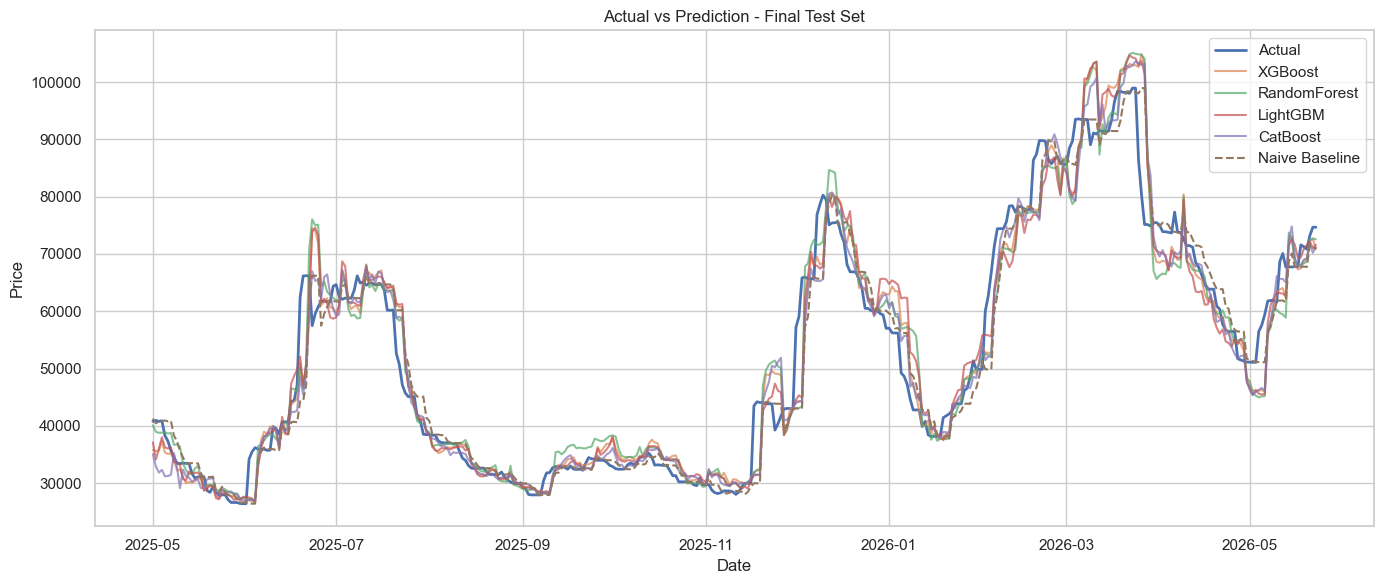

In [369]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df["target_date"],
    y_test.values,
    label="Actual",
    linewidth=2
)

for model_name, pred in final_predictions.items():
    plt.plot(
        test_df["target_date"],
        pred,
        label=model_name,
        alpha=0.7
    )

plt.plot(
    test_df["target_date"],
    baseline_pred.values,
    label="Naive Baseline",
    linestyle="--"
)

plt.title("Actual vs Prediction - Final Test Set")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

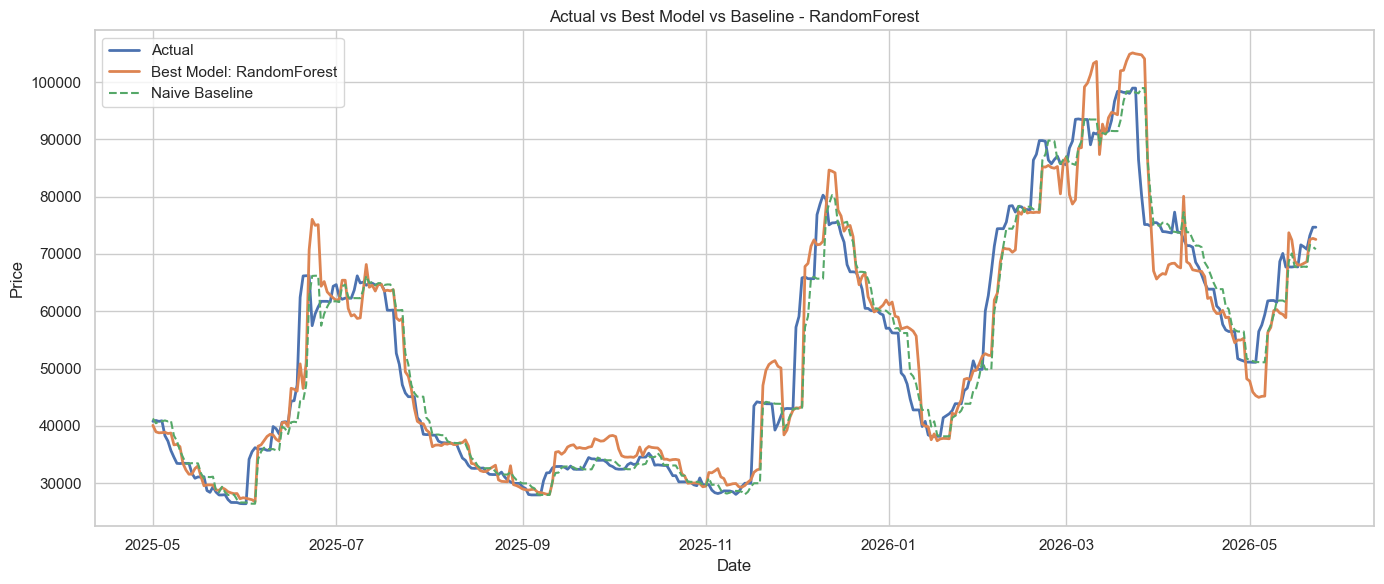

In [370]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_df["target_date"],
    y_test.values,
    label="Actual",
    linewidth=2
)

plt.plot(
    test_df["target_date"],
    best_test_pred,
    label=f"Best Model: {best_model_name}",
    linewidth=2
)

plt.plot(
    test_df["target_date"],
    baseline_pred.values,
    label="Naive Baseline",
    linestyle="--"
)

plt.title(f"Actual vs Best Model vs Baseline - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [371]:
error_df = test_df[["Date", "target_date", "target_price"]].copy()
error_df["prediction"] = best_test_pred
error_df["error"] = error_df["target_price"] - error_df["prediction"]
error_df["absolute_error"] = np.abs(error_df["error"])
error_df["absolute_percentage_error"] = (
    error_df["absolute_error"] / error_df["target_price"]
) * 100

display(error_df.head())

,Date,target_date,target_price,prediction,error,absolute_error,absolute_percentage_error
1183,2025-04-28,2025-05-01,"40,799.00","40,089.87",709.13,709.13,1.74
1184,2025-04-29,2025-05-02,"40,945.00","38,964.09","1,980.91","1,980.91",4.84
1185,2025-04-30,2025-05-03,"40,781.00","38,788.92","1,992.08","1,992.08",4.88
1186,2025-05-01,2025-05-04,"40,890.00","38,819.09","2,070.91","2,070.91",5.06
1187,2025-05-02,2025-05-05,"38,296.00","38,881.24",-585.24,585.24,1.53


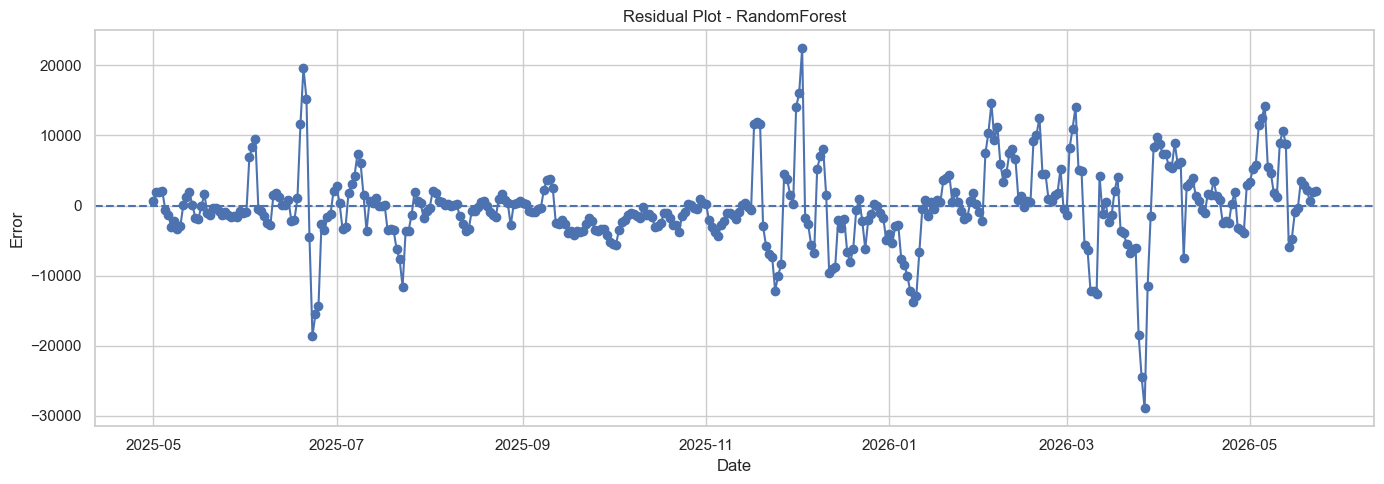

In [372]:
plt.figure(figsize=(14, 5))

plt.plot(
    error_df["target_date"],
    error_df["error"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title(f"Residual Plot - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Error")
plt.tight_layout()
plt.show()

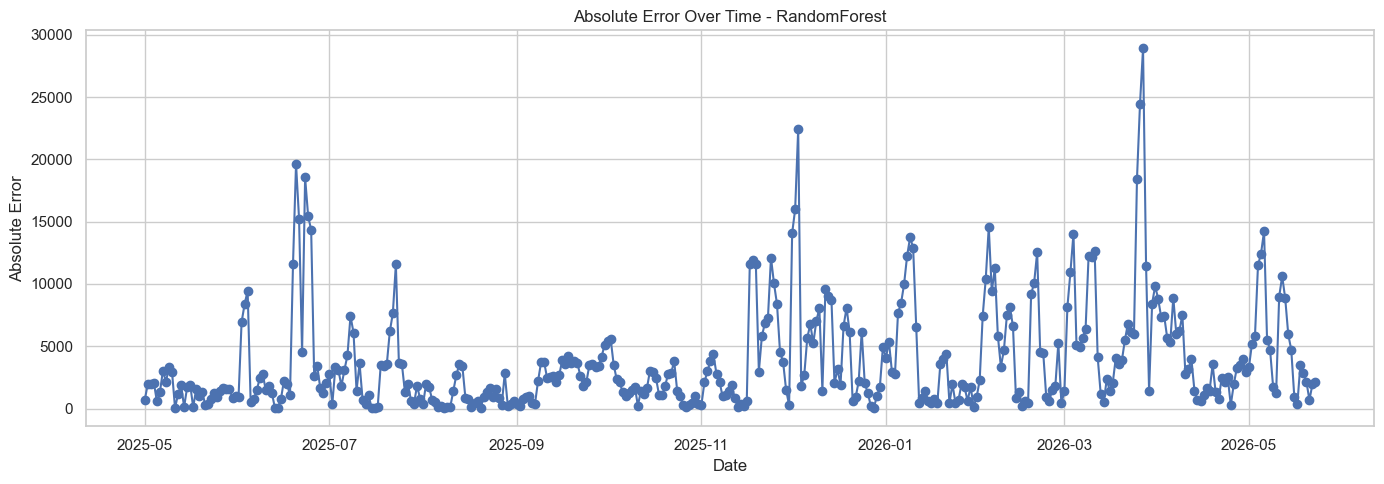

In [373]:
plt.figure(figsize=(14, 5))

plt.plot(
    error_df["target_date"],
    error_df["absolute_error"],
    marker="o"
)

plt.title(f"Absolute Error Over Time - {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Absolute Error")
plt.tight_layout()
plt.show()

Residual analysis dilakukan untuk mengevaluasi pola kesalahan prediksi. Jika residual cenderung sistematis, misalnya sering bernilai positif atau negatif pada periode tertentu, maka model masih memiliki bias terhadap kondisi harga tertentu. Analisis error per bulan juga membantu melihat apakah model lebih lemah pada periode musiman tertentu.

,Feature,Importance
0,current_price,0.94
25,target_weekofyear,0.01
7,lag_30,0.01
19,pct_change_7,0.01
17,diff_7,0.00
6,lag_21,0.00
5,lag_14,0.00
15,rolling_max_7,0.00
11,rolling_mean_30,0.00
13,rolling_std_14,0.00


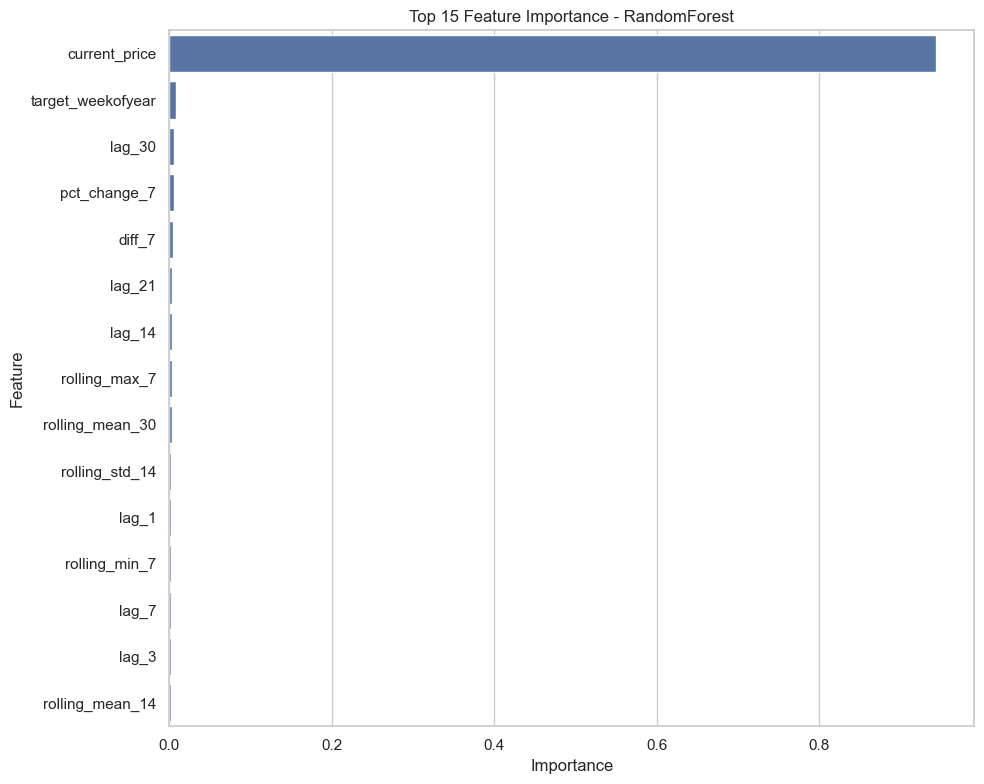

In [374]:
if hasattr(best_model, "feature_importances_"):

    importance_df = pd.DataFrame({
        "Feature": features,
        "Importance": best_model.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance_df)

    plt.figure(figsize=(10, 8))

    sns.barplot(
        data=importance_df.head(15),
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top 15 Feature Importance - {best_model_name}")
    plt.tight_layout()
    plt.show()

else:
    print(f"Model {best_model_name} tidak memiliki attribute feature_importances_.")

# Conclusion

Berdasarkan hasil eksplorasi data, harga cabai rawit menunjukkan fluktuasi yang cukup besar dari waktu ke waktu. Pola tren harian, bulanan, dan tahunan menunjukkan bahwa harga cabai rawit memiliki karakteristik time series yang dipengaruhi oleh perubahan periode dan volatilitas historis.

Pada tahap pemodelan, beberapa model machine learning dibandingkan menggunakan validasi berbasis waktu. Model terbaik dipilih berdasarkan hasil cross-validation, sedangkan final test set digunakan hanya untuk evaluasi akhir. Baseline yang digunakan adalah naive forecast, yaitu mengasumsikan harga 3 hari ke depan sama dengan harga pada hari observasi.

Jika model terbaik mampu menghasilkan MAE, RMSE, MAPE, WAPE, dan sMAPE yang lebih rendah dibandingkan baseline, maka model dapat dianggap memiliki nilai prediktif tambahan. Namun, model ini masih memiliki keterbatasan karena hanya menggunakan data historis harga. Untuk pengembangan berikutnya, model dapat diperkuat dengan fitur eksternal seperti cuaca, hari besar, musim panen, pasokan pasar, dan data wilayah.